In [43]:
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error
import joblib
import numpy as np 
import pandas as pd 
import xgboost as xgb 
import seaborn as sns 
import matplotlib.pyplot as plt

In [28]:
X_train = joblib.load('../data/processed/X_train_scaled.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
X_test = joblib.load('../data/processed/X_test_scaled.pkl')
y_test = joblib.load('../data/processed/y_test.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')
print(f"Ready to train {X_train.shape[0]} samples")

Ready to train 4886 samples


In [29]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
print(f"Baseline MAE: {mean_absolute_error(y_test, y_pred_base):.2f}")

Baseline MAE: 0.23


In [30]:
rows_with_nan = np.where(np.isnan(X_train).any(axis=1))[0]
cols_with_nan = np.where(np.isnan(X_train).any(axis=0))[0]

In [44]:
print("Baseline model: ", r2_score(y_test, y_pred_base))
print(mean_squared_error(y_test, y_pred_base))

Baseline model:  0.8803771130197879
0.0863174975249237


In [32]:
coef_df = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'Coefficient': baseline.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
8,norm__sur_def,0.766489
9,norm__BMXWT,0.015330
15,cat__RIDRETH3_2.0,0.014721
2,skew__carb_g,0.011821
14,cat__RIDRETH3_1.0,0.010900
10,norm__bmr,0.005426
4,skew__calories,0.003688
13,cat__RIAGENDR_2.0,0.002081
16,cat__RIDRETH3_3.0,0.001649
6,norm__BMXHIP,0.000711


In [33]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=6, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    n_jobs=-1
)

In [34]:
xgb_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
xgb_model.fit(X_train, y_train, verbose=100)
y_pred = xgb_model.predict(X_test)

In [36]:
print(f"XGBoost R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"XGBoost MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"XGBoost MAE: {root_mean_squared_error(y_test, y_pred):.2f}")

XGBoost R2 Score: 0.8675
XGBoost MAE: 0.24
XGBoost MAE: 0.31


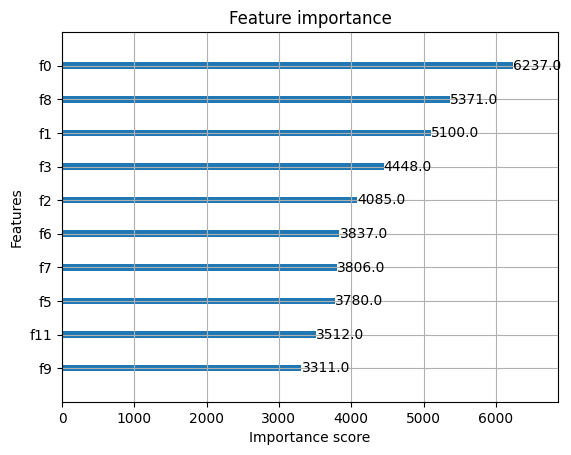

In [37]:
feature_names = preprocessor.get_feature_names_out()
xgb.plot_importance(xgb_model, max_num_features=10)
plt.show()

In [38]:
importance = xgb_model.feature_importances_
feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)
feat_imp.head()

norm__sur_def     0.596742
skew__calories    0.141263
norm__tdee        0.077677
norm__bmr         0.021346
skew__carb_g      0.020543
dtype: float32

In [46]:
joblib.dump(baseline, '../models/linearreg.pkl')
joblib.dump(xgb_model, '../models/xgboost.pkl')

['../models/xgboost.pkl']